In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('IMDB.csv')

In [3]:
print('Dataset shape', df.shape)

Dataset shape (50000, 2)


In [4]:
print('dataset columns', df.columns.to_list())

dataset columns ['review', 'sentiment']


In [5]:
print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [6]:
target_column = 'sentiment'
df[target_column] = df[target_column].map({'positive' : 1, 'negative' : 0})

In [7]:
print(df.head())

                                              review  sentiment
0  One of the other reviewers has mentioned that ...          1
1  A wonderful little production. <br /><br />The...          1
2  I thought this was a wonderful way to spend ti...          1
3  Basically there's a family where a little boy ...          0
4  Petter Mattei's "Love in the Time of Money" is...          1


In [8]:
STOP_WORDS = set([
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours',
    'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers',
    'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves',
    'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are',
    'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does',
    'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until',
    'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into',
    'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down',
    'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here',
    'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more',
    'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so',
    'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should', 'now'
])

In [9]:
def clean_text(text):
    #convert to small letters
    #delete HTML tags
    #delete non alphabetic
    #delete stop words
    #stemming

    text = text.lower()
    text = re.sub(r'<.*?>',' ', text)
    text = re.sub(r'[^a-z\s]', '', text)

    words = text.split()
    cleaned_words = []

    for w in words:
        if w not in STOP_WORDS and len(w)>1:
            if w.endswith('ing'): w = w[:-3]
            elif w.endswith('ed'): w = w[:-2]
            elif w.endswith('s'): w = w[:-1]

            cleaned_words.append(w)

    return cleaned_words

In [10]:
def build_vocab(all_docs, max_words=5000):
    #all docs: Clean_text output
    #max words: number of words

    word_counts = {}
    for doc in all_docs:
        for word in doc:
            word_counts[word] = word_counts.get(word, 0) + 1

    sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)

    vocab_list = [w[0] for w in sorted_words[:max_words]]

    vocab_map = {word: i for i, word in enumerate(vocab_list)}

    return vocab_map

In [11]:
def vectorize(doc, vocab_map):
    vector = np.zeros(len(vocab_map), dtype=int)

    for word in doc:
        if word in vocab_map:
            index = vocab_map[word]
            vector[index] = 1

    return vector

Naive Bayes

In [ ]:
class Naive_Bayes():
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.class_log_prior = {}
        self.feature_log_prob = {}
        self.classes = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)

        for c in self.classes:
            X_c = X[y==c]
            self.class_log_prior[c] = np.log(X_c.shape[0] / n_samples)
            
            count_w_c = np.sum(X_c, axis=0)

            count_c = np.sum(count_w_c)

            # P(w|c) = (count(w,c) + alpha) / (count(c) + alpha * vocab_size)
            prob_w_c = (count_w_c + self.alpha) / (count_c + self.alpha * n_features)

            self.feature_log_prob[c] = np.log(prob_w_c)
    
    def predict(self, X):
        predictions = []
        for x in X:
            class_scores = {}
            for c in self.classes:
                #log(P(c|x)) ~ log(P(c)) + sum(log(P(w|c)))
                log_prob = self.class_log_prior[c] + np.dot(x, self.feature_log_prob[c])
                class_scores[c] = log_prob
            
            best_class = max(class_scores, key=class_scores.get)
            predictions.append(best_class)

        return np.array(predictions)

In [13]:
def calculate_f1(y_true, y_pred):
    TP = np.sum((y_true==1) & (y_pred==1))
    FP = np.sum((y_true==0) & (y_pred==1))
    TN = np.sum((y_true==0) & (y_pred==0))
    FN = np.sum((y_true==1) & (y_pred==0))

    precision = TP / (TP + FP + 1e-10)
    recall = TP / (TP + FN + 1e-10)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-10)

    return TP, FP, TN, FN, precision, recall, f1


In [14]:
df['cleaned'] = df['review'].apply(clean_text)

In [15]:
def train_test_split(df, test_size=0.2, valid_size=0.2):
    n = len(df)
    train_size= 1 - (test_size + valid_size)

    np.random.seed(42)
    shuffled_indices = np.random.permutation(n)

    train_idx = shuffled_indices[:int(train_size * n)]
    val_idx = shuffled_indices[int(train_size * n) : int((train_size + valid_size) * n)]
    test_idx = shuffled_indices[int((train_size+valid_size)*n) :]

    train_docs = df.iloc[train_idx][['cleaned']].values.flatten()
    val_docs = df.iloc[val_idx][['cleaned']].values.flatten()
    test_docs = df.iloc[test_idx][['cleaned']].values.flatten()

    y_train = df.iloc[train_idx][target_column].values.flatten()
    y_val = df.iloc[val_idx][target_column].values.flatten()
    y_test = df.iloc[test_idx][target_column].values.flatten()

    return train_docs, val_docs, test_docs, y_train, y_val, y_test

In [ ]:
def test_feature_length(train_docs, val_docs, y_train, y_val):
    feature_lengths = [100, 500, 1000, 2000, 5000]
    f1_score_len = []

    for len in feature_lengths:
        vocab = build_vocab(train_docs, max_words=len)

        X_train = np.array([vectorize(d, vocab) for d in train_docs])
        X_val = np.array([vectorize(d, vocab) for d in val_docs])

        nb = Naive_Bayes(alpha=1.0)
        nb.fit(X_train, y_train)

        y_pred = nb.predict(X_val)
        *_, score = calculate_f1(y_val, y_pred)
        f1_score_len.append(score)
        print(f"Length: {len}, F1-Score: {score:.4f}")

    plt.figure(figsize=(8,5))
    plt.plot(feature_lengths, f1_score_len, marker='o')
    plt.title('F1-score vs Feature vector length')
    plt.xlabel('Vector length')
    plt.ylabel('F1-score')
    plt.grid(True)
    plt.show()

In [17]:
def test_alpha(train_docs, val_docs, y_train, y_val):
    alphas = [0.001, 0.1, 1.0, 5.0, 10.0, 50.0]
    f1_scores_alpha = []
    best_len = 1000
    
    vocab = build_vocab(train_docs, max_words=best_len)

    X_train = np.array([vectorize(d, vocab) for d in train_docs])
    X_val = np.array([vectorize(d, vocab) for d in val_docs])

    for alpha in alphas:
        nb = Naive_Bayes(alpha=alpha)
        nb.fit(X_train, y_train)
        y_pred = nb.predict(X_val)
        *_, score = calculate_f1(y_val, y_pred)
        f1_scores_alpha.append(score)
        print(f"Alpha: {alpha}, F1-Score: {score:.4f}")

    plt.figure(figsize=(8, 5))
    plt.plot(alphas, f1_scores_alpha, marker='o', color='orange')
    plt.xscale('log')
    plt.title('F1-Score vs Laplace Alpha')
    plt.xlabel('Alpha (Log Scale)')
    plt.ylabel('F1-Score')
    plt.grid(True)
    plt.show()


Length: 100, F1-Score: 0.7150
Length: 500, F1-Score: 0.8218
Length: 1000, F1-Score: 0.8374
Length: 2000, F1-Score: 0.8410
Length: 5000, F1-Score: 0.8489


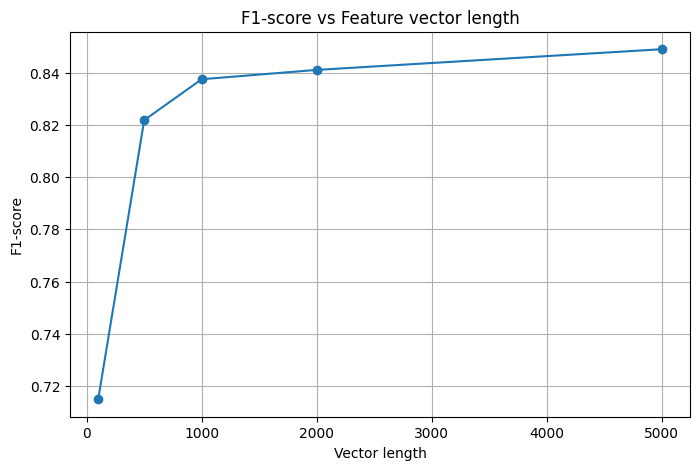

Alpha: 0.001, F1-Score: 0.8374
Alpha: 0.1, F1-Score: 0.8374
Alpha: 1.0, F1-Score: 0.8374
Alpha: 5.0, F1-Score: 0.8374
Alpha: 10.0, F1-Score: 0.8371
Alpha: 50.0, F1-Score: 0.8359


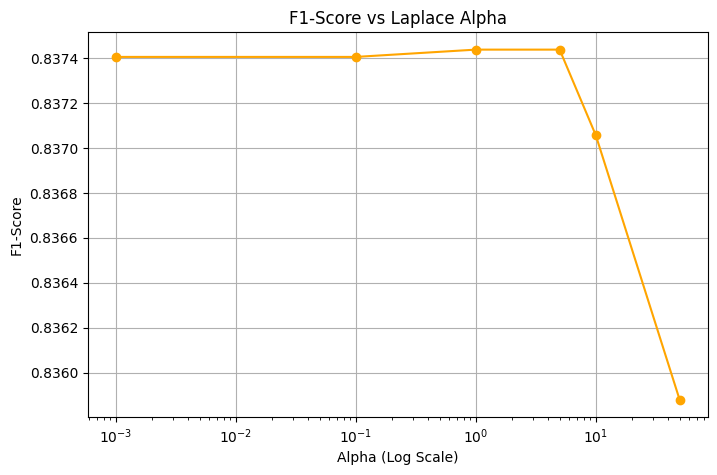

In [18]:
train_docs, val_docs, test_docs, y_train, y_val, y_test = train_test_split(df, test_size=0.2, valid_size=0.2)

test_feature_length(train_docs, val_docs, y_train, y_val)
test_alpha(train_docs, val_docs, y_train, y_val)


Final model

In [19]:
best_alpha = 1.0
best_len = 5000

all_train_docs = np.concatenate((train_docs, val_docs))
all_y_train = np.concatenate((y_train, y_val))

final_vocab = build_vocab(all_train_docs, max_words=best_len)

X_all_train = np.array([vectorize(d, final_vocab) for d in all_train_docs])
X_test = np.array([vectorize(d, final_vocab) for d in test_docs])

final_model = Naive_Bayes(alpha=best_alpha)
final_model.fit(X_all_train, all_y_train)

y_test_pred = final_model.predict(X_test)
*_, final_f1 = calculate_f1(y_test, y_test_pred)

print(f"Final Test F1-Score: {final_f1:.4f}")

Final Test F1-Score: 0.8469


In [25]:
def plot_confusion_matrix(y_true, y_pred):
    
    TP, FP, TN, FN, precision, recall, f1 =  calculate_f1(y_true, y_pred)

    cm = np.array([[TN, FP], [FN, TP]])
    
    fig, ax = plt.subplots()
    cax = ax.matshow(cm, cmap='Blues')
    plt.title('Confusion Matrix')
    fig.colorbar(cax)
    
    for (i, j), z in np.ndenumerate(cm):
        ax.text(j, i, str(z), ha='center', va='center', color='red')
    
    plt.xlabel('Predicted')
    plt.ylabel('True')
    ax.set_xticklabels(['', 'Neg', 'Pos'])
    ax.set_yticklabels(['', 'Neg', 'Pos'])
    plt.show()

C:\Users\ferdo\AppData\Local\Temp\ipykernel_19944\2014587914.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['', 'Neg', 'Pos'])
C:\Users\ferdo\AppData\Local\Temp\ipykernel_19944\2014587914.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['', 'Neg', 'Pos'])


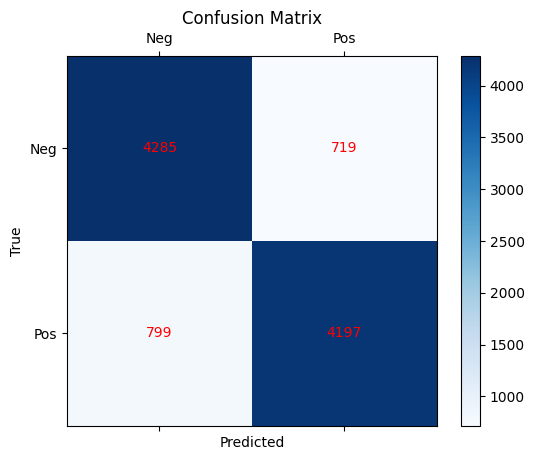

In [26]:
plot_confusion_matrix(y_test, y_test_pred)